## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.19 強化學習，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 23｜強化學習_策略價值與深度RL

以兩臂 bandit 示範探索、回饋與增量式價值估計。

對應 `slides/23_強化學習_策略價值與深度RL.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/19_reinforcement_learning.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Neural Network Policies、Policy Gradients、Q-Learning 區段。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
true_means = np.array([0.2, 0.8])
Q = np.zeros(2); counts = np.zeros(2, dtype=int); rewards = []
epsilon = 0.12
for step in range(300):
    action = rng.integers(2) if rng.random() < epsilon else int(np.argmax(Q))
    reward = rng.normal(true_means[action], 0.25)
    counts[action] += 1
    Q[action] += (reward - Q[action]) / counts[action]
    rewards.append(reward)
pd.DataFrame({'arm': [0,1], 'pulls': counts, 'estimated_value': Q, 'true_mean': true_means}).round(3)

,arm,pulls,estimated_value,true_mean
0,0,21,0.156,0.2
1,1,279,0.805,0.8


## 執行結果圖

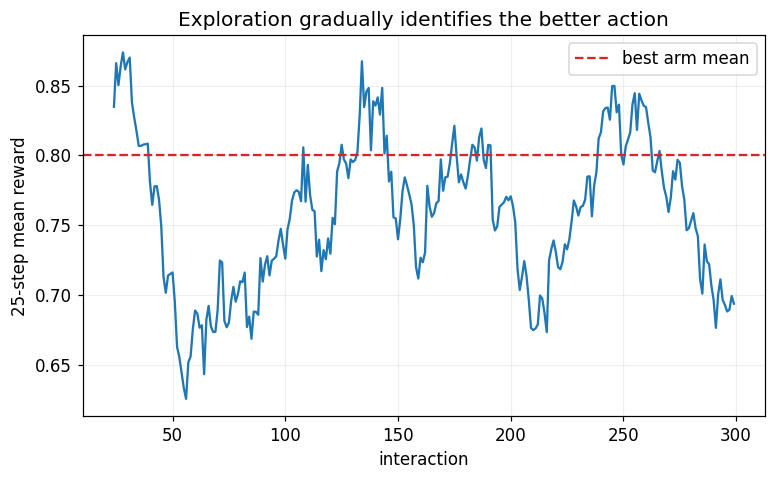

In [3]:
rewards = np.array(rewards)
moving = np.convolve(rewards, np.ones(25)/25, mode='valid')
plt.plot(np.arange(24, len(rewards)), moving)
plt.axhline(true_means.max(), color='tab:red', ls='--', label='best arm mean')
plt.xlabel('interaction'); plt.ylabel('25-step mean reward'); plt.title('Exploration gradually identifies the better action')
plt.legend()
savefig('23_rl_demo')
report('reinforcement_learning', {'counts': counts.tolist(), 'Q': Q.tolist(), 'mean_reward': rewards.mean()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。